In [1]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='pytensor')

In [3]:
SEED = 12

In [4]:
pizza = pd.read_csv('../data/pizza_sales.csv', index_col=0)

In [5]:
pizza = pizza.head(500).copy()

In [6]:
pizza['order_time'] = pd.to_datetime(pizza['order_time'], format='%H:%M:%S')

In [7]:
pizza['order_time_continuous'] = (
    pizza['order_time'].dt.hour +
    pizza['order_time'].dt.minute / 60 +
    pizza['order_time'].dt.second / 3600
)

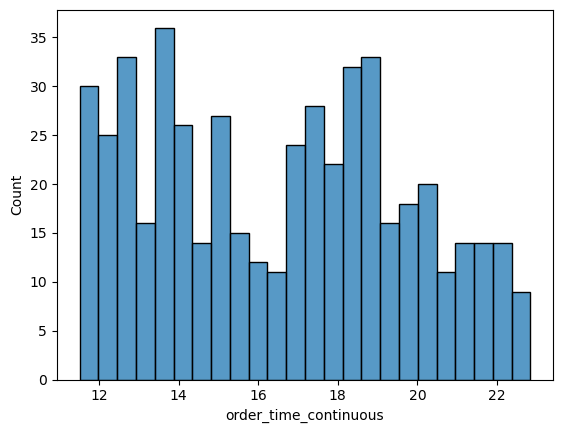

In [8]:
sns.histplot(pizza['order_time_continuous'], bins=24);

## 1.
Plantear un modelo de mezcla finita (por ejemplo, mezcla de dos o más normales) y justificar la elección.

In [9]:
obs = pizza['order_time_continuous'].values

In [10]:
k = 2

with pm.Model() as model:
        w = pm.Dirichlet('w', a=np.ones(k))
        μ = pm.Normal('μ', mu=13, sigma=5, shape=k)
        σ = pm.HalfNormal('σ', sigma=5)

        x = pm.NormalMixture('x', w=w, mu=μ, sigma=σ, observed=obs)

        idata = pm.sample(random_seed=SEED, idata_kwargs={"log_likelihood":True}) 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 39 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## 2.
Analizar la identificabilidad del modelo y discutir posibles problemas de simetría entre componentes.


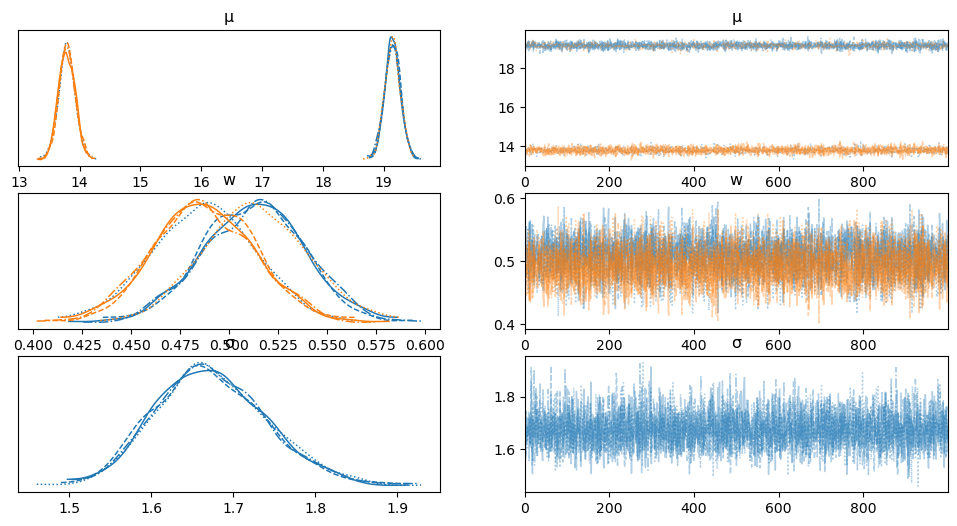

In [12]:
az.plot_trace(idata);

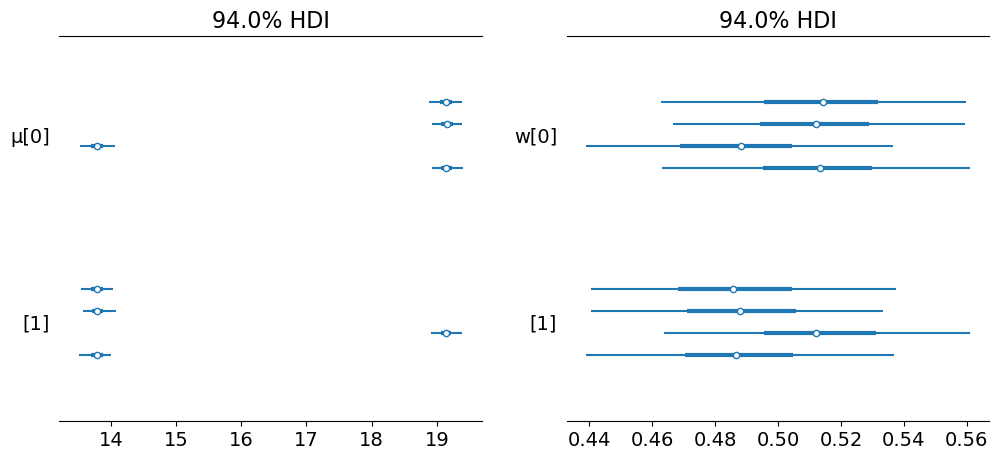

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

az.plot_forest(idata, var_names=['μ'], ax=axes[0])
az.plot_forest(idata, var_names=['w'], ax=axes[1]);

Para solucionar hay 2 opciones:
1. usar priors más informativos (es lo que hacemos)
2. ordenar

In [16]:
k = 2

with pm.Model() as model:
        w = pm.Dirichlet('w', a=np.ones(k))
        μ = pm.Normal('μ', mu=[12, 18], sigma=5, shape=k)
        σ = pm.HalfNormal('σ', sigma=5)

        x = pm.NormalMixture('x', w=w, mu=μ, sigma=σ, observed=obs)

        idata = pm.sample(random_seed=SEED) 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.


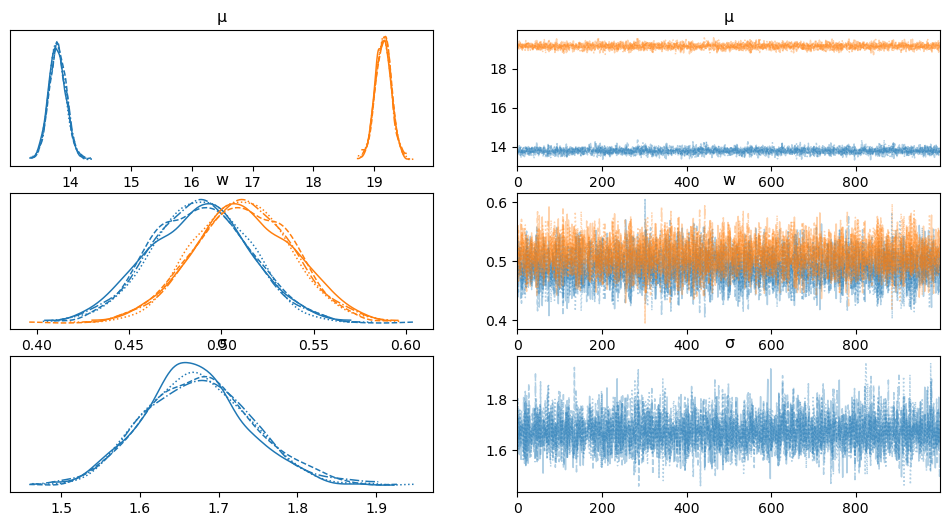

In [17]:
az.plot_trace(idata);

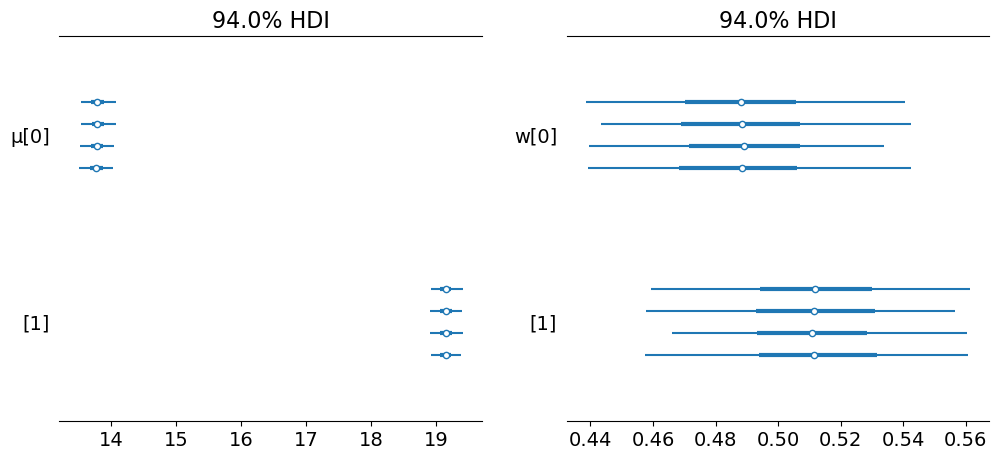

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

az.plot_forest(idata, var_names=['μ'], ax=axes[0])
az.plot_forest(idata, var_names=['w'], ax=axes[1]);

In [20]:
az.summary(idata, kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],0.002,0.002,3554.0,2968.0,1.0
μ[1],0.002,0.002,3865.0,3352.0,1.0
w[0],0.000,0.000,3817.0,3326.0,1.0
w[1],0.000,0.000,3817.0,3326.0,1.0
σ,0.001,0.001,5553.0,3487.0,1.0


Vemos que onda con la posterior predictive

In [21]:
with model:
    pm.sample_posterior_predictive(idata, random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

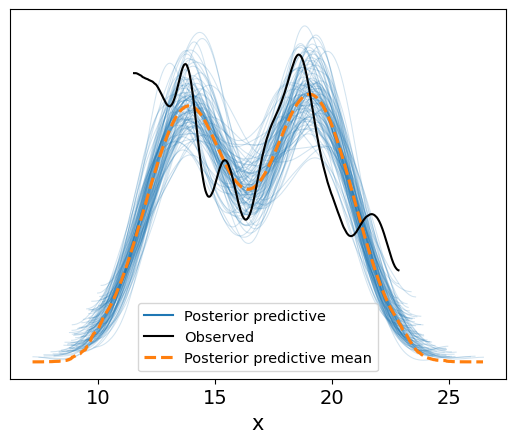

In [22]:
az.plot_ppc(idata, num_pp_samples=100);

Tenemos predicciones para horas en las que la pizzeria esta cerrada. Generalmente para estos casos se usan distribuciones circulares, pero es un embole. Vamos a usar una mezcla de normales truncadas en los horarios de apertura y cierre de la pizzeria.

In [24]:
obs.min(), obs.max()

(np.float64(11.513333333333334), np.float64(22.841388888888886))

In [40]:
k = 2

with pm.Model() as modelo_truncado:
    w = pm.Dirichlet('w', a=np.ones(k))
    μ = pm.TruncatedNormal('μ', mu=[12, 18], sigma=1, lower=11.5, upper=23, shape=k)

    σ = pm.HalfNormal('σ', sigma=3)

    comp_dists = [pm.TruncatedNormal.dist(mu=μ[i], sigma=σ, lower=11.5, upper=23) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comp_dists, observed=obs)

    idata_truncado = pm.sample(target_accept=0.95, random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 71 seconds.


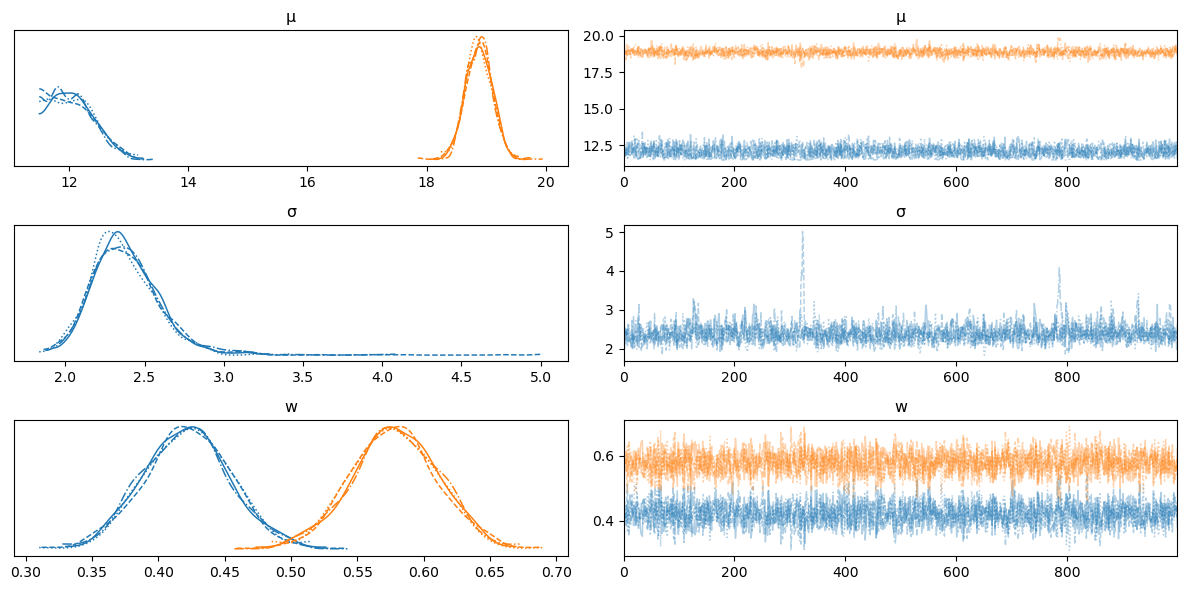

In [42]:
az.plot_trace(idata_truncado, var_names=['μ', 'σ', 'w'])
plt.tight_layout();

In [43]:
with modelo_truncado:
    pm.sample_posterior_predictive(idata_truncado, random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

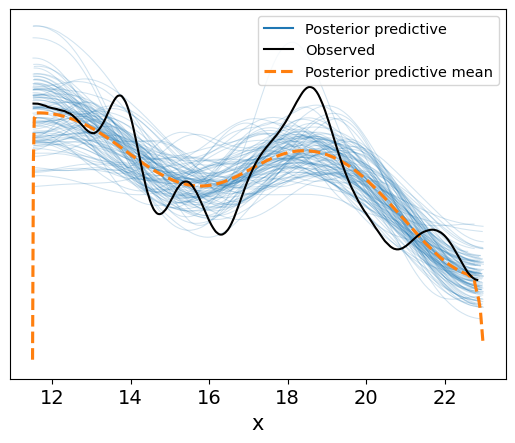

In [44]:
az.plot_ppc(idata_truncado, num_pp_samples=100);

## 3.
Comparar distintos valores de K (número de componentes) y evaluar cuál describe mejor los datos.

Mientras más K, más informativos deben ser los priors (menor $\sigma$)

In [57]:
obs.std() /2

np.float64(1.5771954484367985)

In [58]:
Ks = [2, 3, 4]

idatas = []
modelos = []

for k in Ks:
    with pm.Model() as modelo:
        w = pm.Dirichlet('w', a=np.ones(k))
        μ = pm.TruncatedNormal(
            'μ',
            mu=np.quantile(obs, np.linspace(0.1, 0.9, k)),
            sigma=1/k,
            lower=11.5,
            upper=23.0,
            shape=k
            )

        σ = pm.HalfNormal('σ', sigma=2)

        comp_dists = [pm.TruncatedNormal.dist(mu=μ[i], sigma=σ, lower=11.5, upper=23.0) for i in range(k)]

        x = pm.Mixture('x', w=w, comp_dists=comp_dists, observed=obs)

        idata = pm.sample(target_accept=0.95, random_seed=SEED, idata_kwargs={"log_likelihood": True})

        idatas.append(idata)
        modelos.append(modelo)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 68 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 114 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 168 seconds.


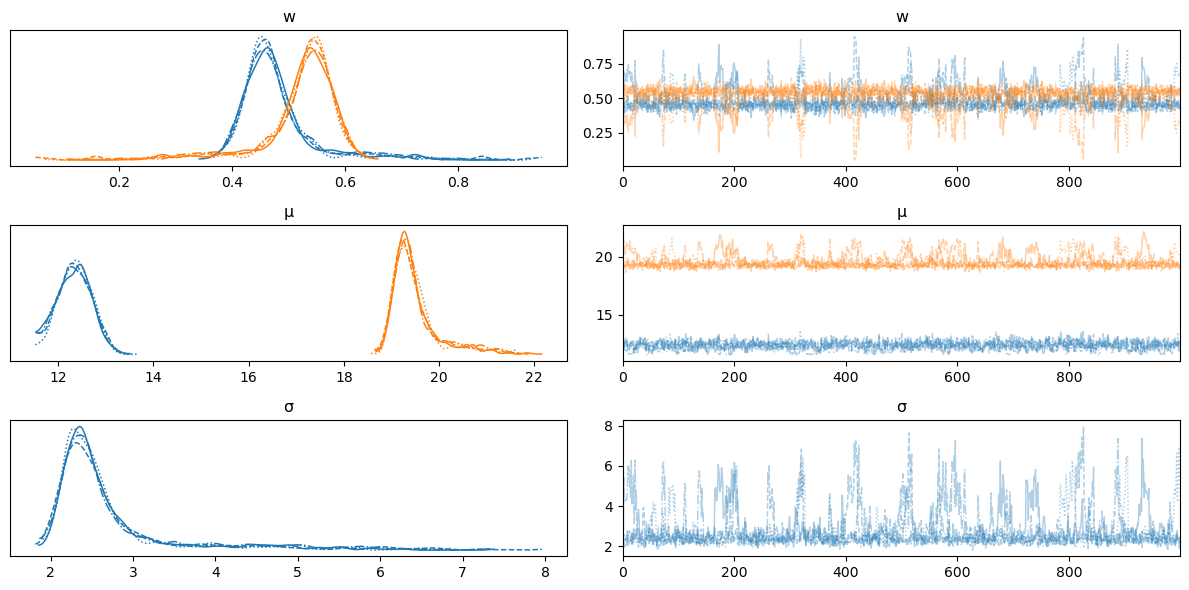

In [59]:
az.plot_trace(idatas[0])
plt.tight_layout();

Las trazas parecen tener algún problema pero nada muy importante, el $\hat{R}$ y el ESS están dentro de lo aceptable (por poco).

In [60]:
az.summary(idatas[0], kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w[0],0.004,0.005,456.0,522.0,1.0
w[1],0.004,0.005,456.0,522.0,1.0
μ[0],0.010,0.007,1193.0,796.0,1.0
μ[1],0.032,0.033,428.0,471.0,1.0
σ,0.050,0.063,434.0,518.0,1.0


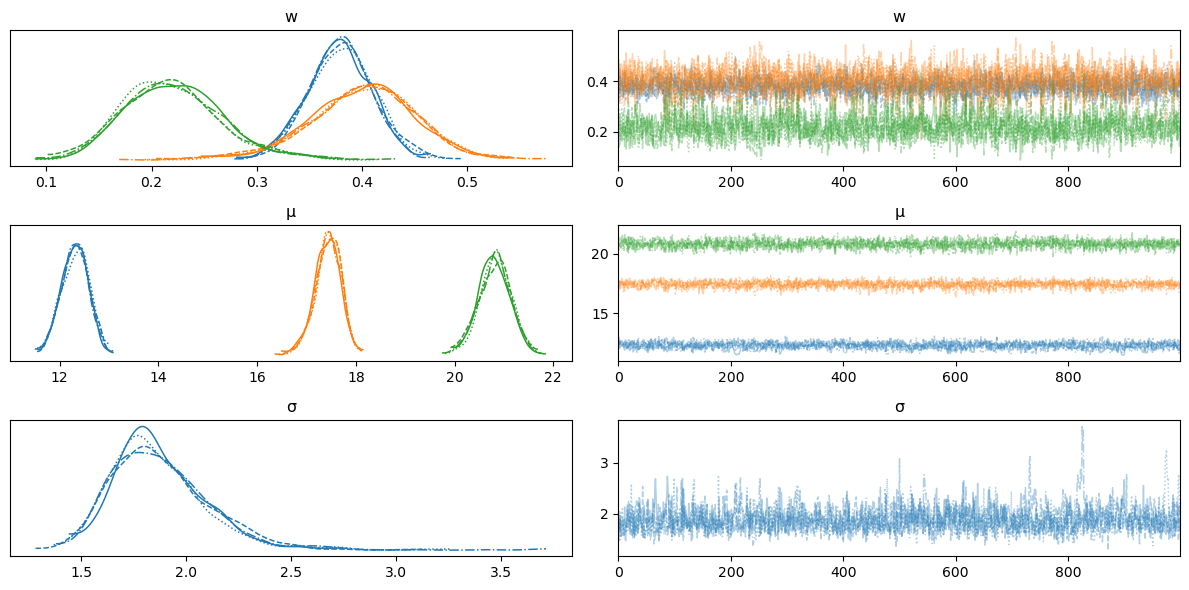

In [61]:
az.plot_trace(idatas[1])
plt.tight_layout();

In [62]:
az.summary(idatas[1], kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w[0],0.001,0.000,2160.0,2445.0,1.0
w[1],0.001,0.001,2100.0,1953.0,1.0
w[2],0.001,0.001,1514.0,1977.0,1.0
μ[0],0.007,0.004,1488.0,1381.0,1.0
μ[1],0.006,0.004,1673.0,2655.0,1.0
μ[2],0.008,0.005,1794.0,2342.0,1.0
σ,0.007,0.009,1444.0,1487.0,1.0


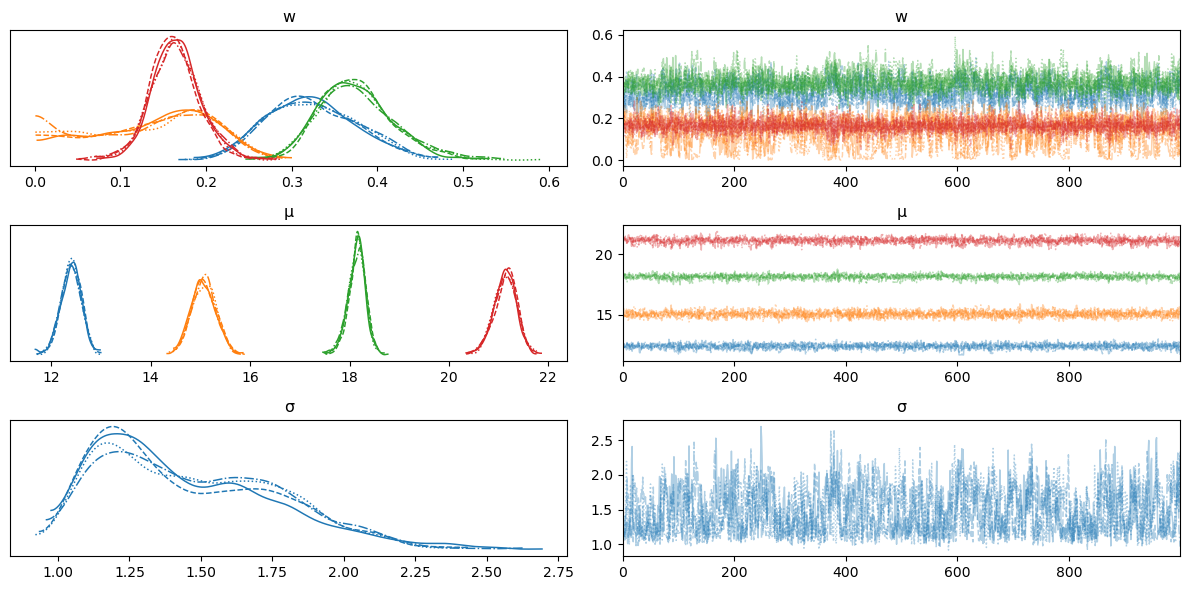

In [63]:
az.plot_trace(idatas[2])
plt.tight_layout();

In [64]:
az.summary(idatas[2], kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w[0],0.002,0.001,718.0,1491.0,1.0
w[1],0.003,0.001,566.0,624.0,1.0
w[2],0.001,0.001,1169.0,1105.0,1.0
w[3],0.001,0.001,2899.0,2255.0,1.0
μ[0],0.004,0.005,2255.0,1421.0,1.0
μ[1],0.005,0.004,2174.0,2319.0,1.0
μ[2],0.004,0.003,1982.0,2188.0,1.0
μ[3],0.006,0.004,1535.0,2110.0,1.0
σ,0.013,0.005,612.0,1470.0,1.0


In [66]:
df_comp = az.compare({f'k={k}': idata for k, idata in zip(Ks, idatas)})
df_comp

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
k=4,0,-1200.247726,5.499959,0.000000,1.000000e+00,6.512014,0.000000,False,log
k=3,1,-1202.497479,4.077191,2.249753,2.498002e-15,5.718019,1.615529,False,log
k=2,2,-1205.497557,4.909582,5.249830,4.440892e-15,5.001341,2.655486,False,log


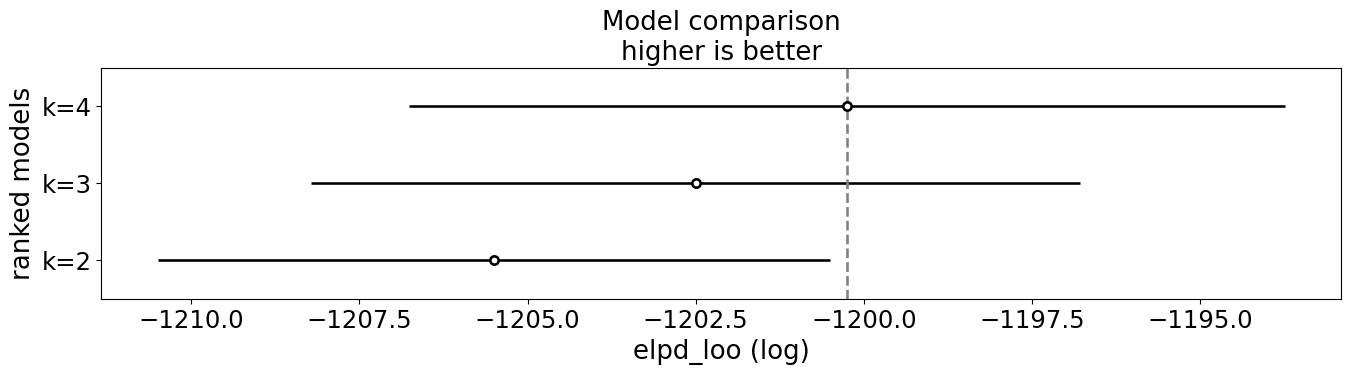

In [68]:
az.plot_compare(df_comp, figsize=(16, 3));

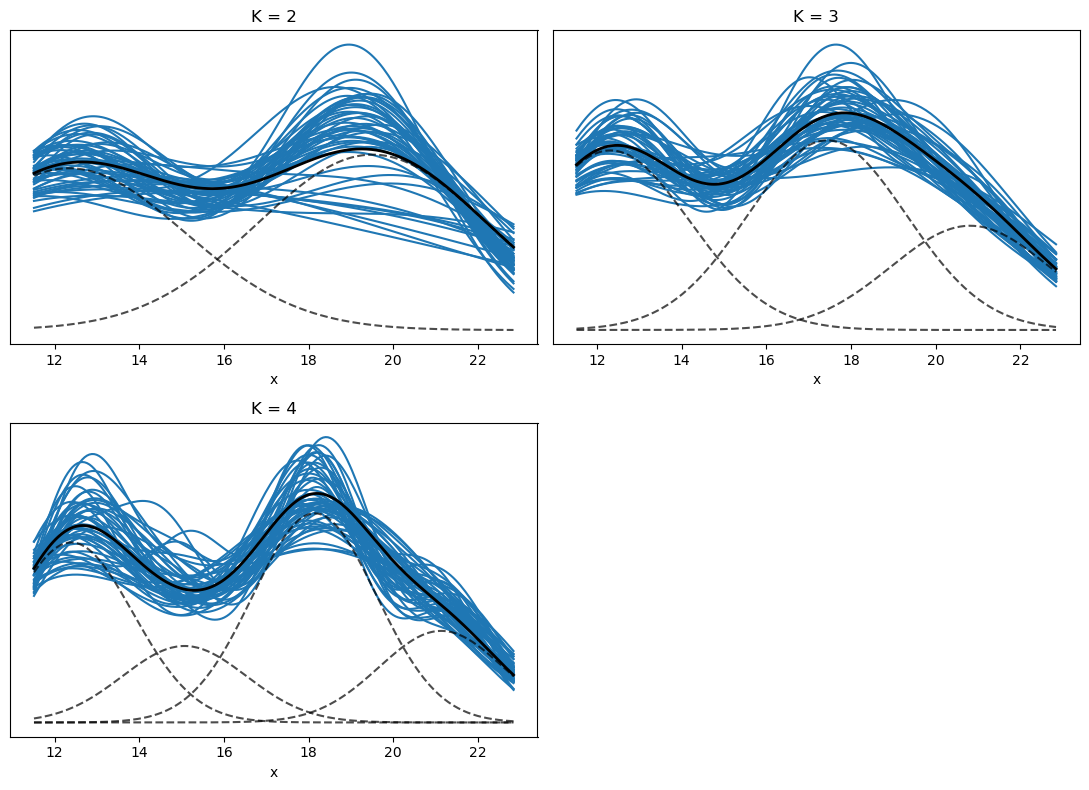

In [72]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

fig.delaxes(ax[1,1])

ax = np.ravel(ax)
x = np.linspace(obs.min(), obs.max(), 200)
for idx, idata_x in enumerate(idatas):
    posterior_x = idata_x.posterior.stack(samples=("chain", "draw"))
    x_ = np.array([x] * Ks[idx]).T

    for i_ in np.random.randint(0, posterior_x.samples.size, size=50):
        dist = pz.Normal(posterior_x['μ'][:,i_], posterior_x['σ'][i_])
        ax[idx].plot(x, np.sum(dist.pdf(x_) *  posterior_x['w'][:,i_].values, 1), 'C0')
 
    p_y = posterior_x['w'].mean("samples")
    dist = pz.Normal(posterior_x['μ'].mean("samples"), posterior_x['σ'].mean())
    ax[idx].plot(x, np.sum(dist.pdf(x_) * p_y.values, 1), 'k', lw=2)
    ax[idx].plot(x, dist.pdf(x_) * p_y.values, 'k--', alpha=0.7)
         
    ax[idx].set_title('K = {}'.format(Ks[idx]))
    ax[idx].set_yticks([])
    ax[idx].set_xlabel('x')

plt.tight_layout();

In [70]:
for i, modelo in enumerate(modelos):
    with modelo:
        pm.sample_posterior_predictive(idatas[i], random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

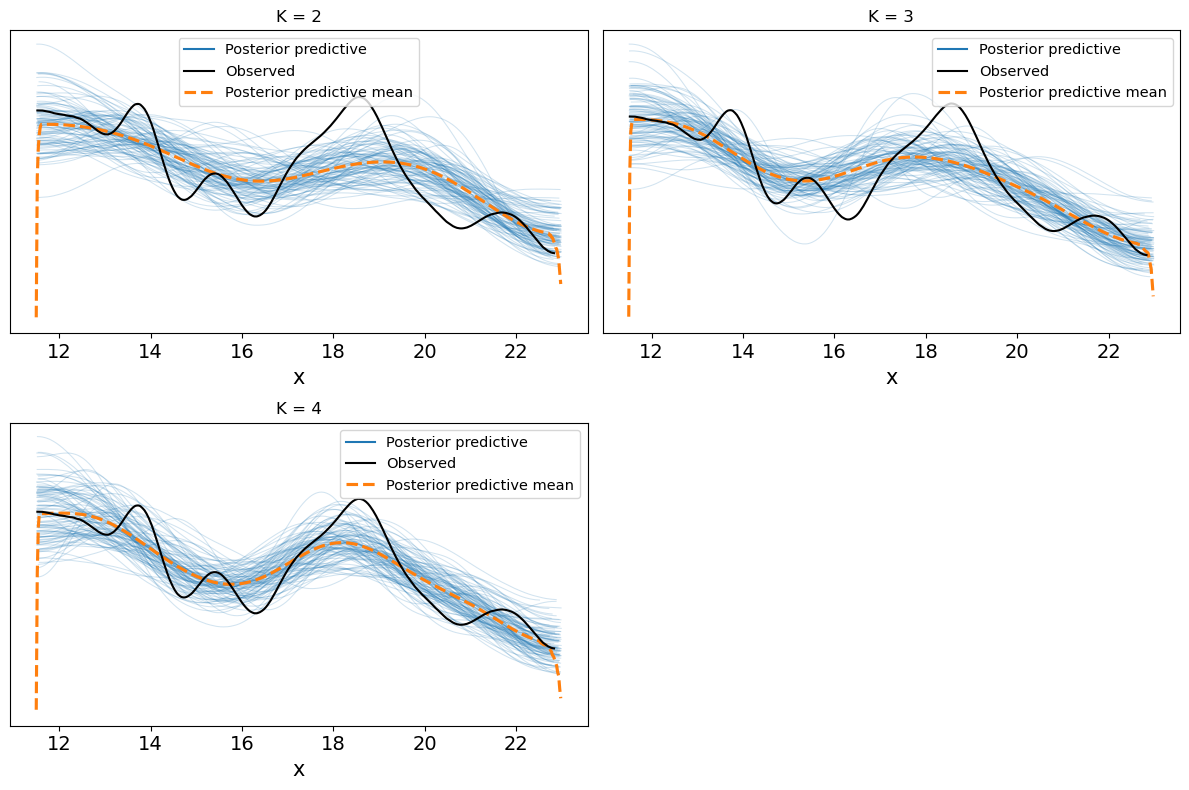

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fig.delaxes(axes[1,1])

axes = np.ravel(axes)
for i, idata in enumerate(idatas):
    az.plot_ppc(idata, num_pp_samples=100, ax=axes[i])
    axes[i].set_title('K = {}'.format(Ks[i]))

plt.tight_layout();

A todo esto, cuales son las horas pico?

según nuestro mejor modelo hay 4 grupos (4 horarios principales).

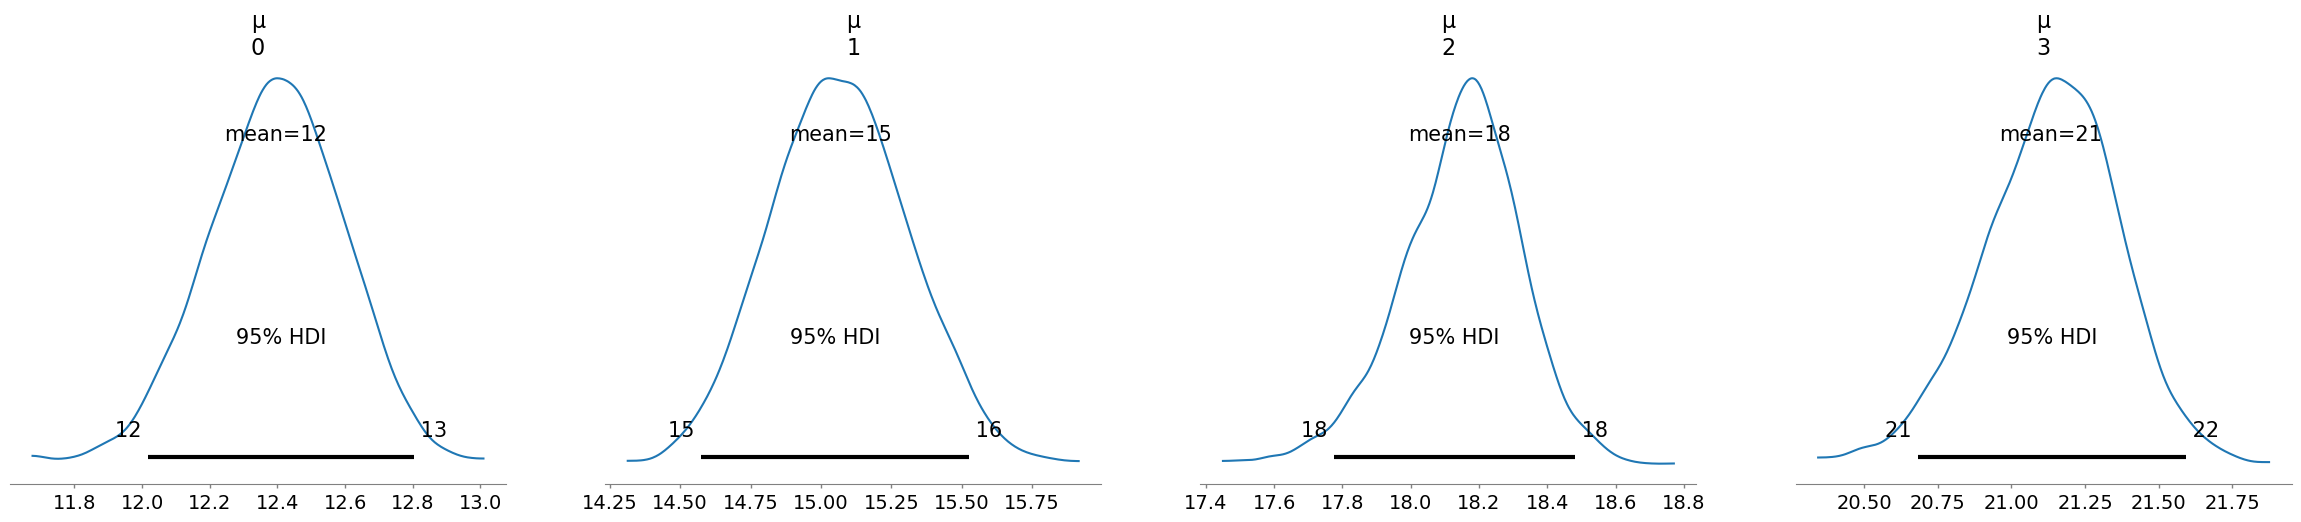

In [77]:
az.plot_posterior(idatas[2], var_names=['μ'], hdi_prob=0.95);

Las 12, 15, 18 y 21 hs son los horarios que le dan forma a nuestra data.  
Para saber cuales son horarios pico podemos ver los pesos

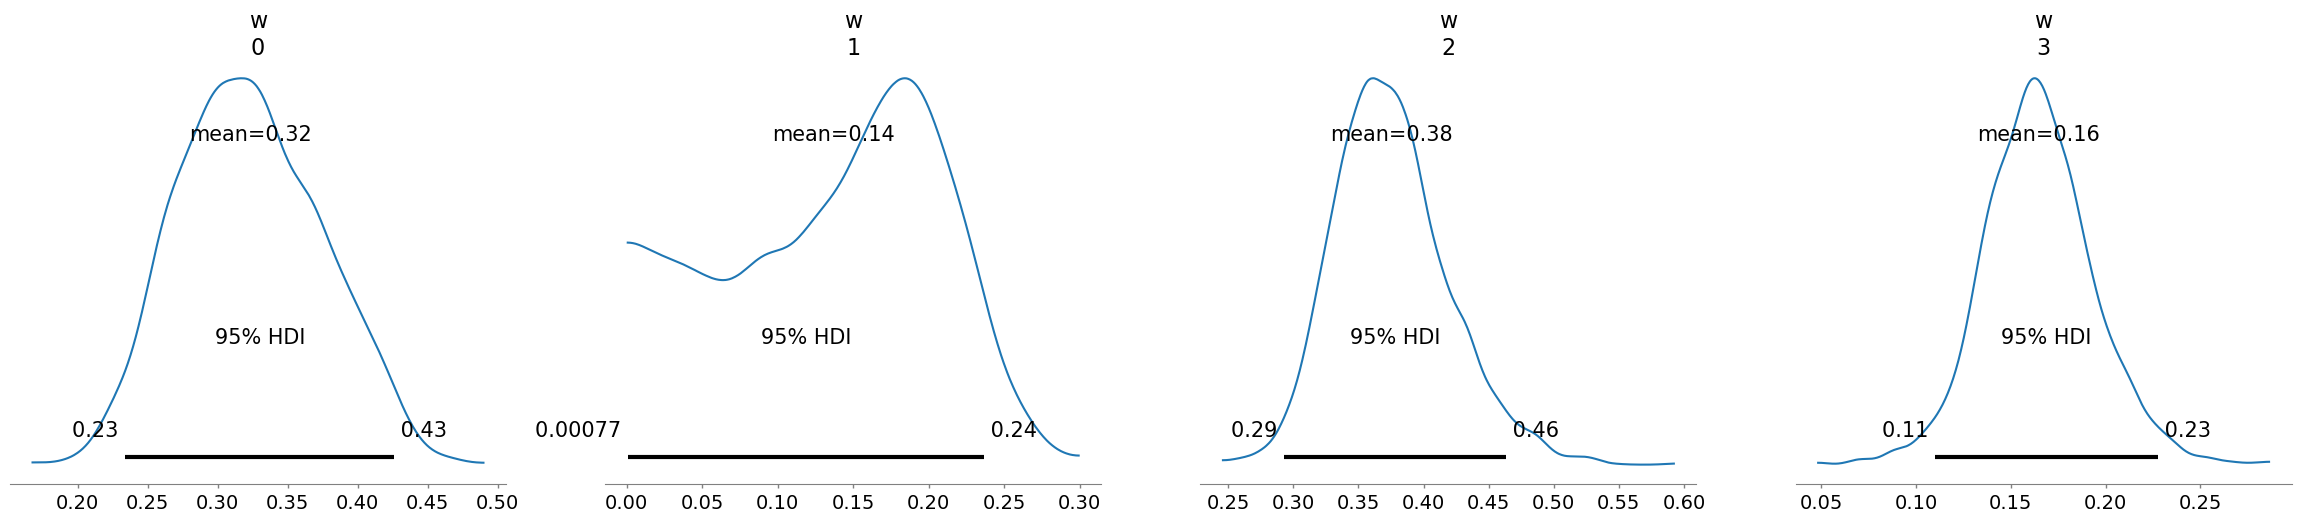

In [78]:
az.plot_posterior(idatas[2], var_names=['w'], hdi_prob=0.95);

Entiendo que esto nos dice que las horas más activas son alrededor de las 18, seguido por las 12, las 21 y las 15, en ese orden.